In [188]:
import numpy as np
import scipy.sparse as sp
import time
from dolphindes.cvxopt import DenseSharedProjQCQP, OptimizationHyperparameters

# conda clean --all

In [189]:
# Physical constants
epsilon_0 = 8.854e-12 # F/m
mu_0 = 4e-7 * np.pi # H/m
c = 1/np.sqrt(epsilon_0 * mu_0) # speed of light in vacuum

E0 = 1e5 # plane wave amplitude in V/m

frequency = 2.45e9 # frequency in Hz
wavelength = c / frequency # wavelength in m
print(f"Wavelength: {wavelength} m")

ka = 1 # electrical size of the antenna
k = 2 * np.pi / wavelength # wavenumber
a = ka / k # antenna circumradius
print(f"Antenna circumradius: {a} m")

omega = 2 * np.pi * frequency # angular frequency

conductivity_reduction_factor = 1e-9 # factor to reduce conductivity for testing purposes
copper_conductivity = conductivity_reduction_factor*5.96e7 # S/m
copper_permittivity = 1 + 1j * copper_conductivity / (omega * epsilon_0) # copper permittivity in dimensionless units
print(f"Copper permittivity: {copper_permittivity:.2e}")

Wavelength: 0.1223655664053944 m
Antenna circumradius: 0.019475084757658086 m
Copper permittivity: 1.00e+00+4.37e-01j


In [190]:
# Calculate surface impedance
delta = np.sqrt(2 / (omega * mu_0 * copper_conductivity)) # skin depth in m
Zs = (1 + 1j) / (copper_conductivity * delta)
# Zs = 1 / (copper_conductivity * delta)
print(f"Surface impedance: {Zs} Ω/square")
print(f"Surface conductance: {1/Zs} S*square")
print(f"Equivalent susceptibility: {-1j/Zs}")

# Load matrices from text files
Lmat = np.loadtxt(r"Lmat_dipole.txt", delimiter=',') # lossy matrix

Ndes = Lmat.shape[0] # number of design variables
print("Number of design variables: ", Ndes)

Lchol = np.linalg.cholesky(Lmat).conj().T
LcholInv = np.linalg.inv(Lchol)

def Msym(M):
    return(0.5*(M.conj().T + M))

def Mchol(M):
    return(Msym(LcholInv.conj().T @ M @ LcholInv))

R0 = np.loadtxt(r"R0_dipole.txt", delimiter=',') # radiated power matrix
R0 = Mchol(R0)

X0 = np.loadtxt(r"X0_dipole.txt", delimiter=',') # reactive power matrix
X0 = Mchol(X0)

Vinc = np.loadtxt(r"V_dipole.txt", delimiter=',') # voltage excitation vector
Vinc = E0*Vinc
def Vchol(v):
    return(LcholInv.conj().T @ Vinc)
Vinc = Vchol(Vinc)

Zmat = Zs * Mchol(Lmat) # material impedance matrix
Z0 = R0 + 1j*X0 # free-space impedance matrix
Ztot = Z0 + Zmat # total impedance matrix
Rmat = np.real(Zmat) # rezistivity matrix

Vzero = np.zeros((Ndes,), dtype=complex) # zero vector

Obj = -0.5 * R0
obj = Vzero/2
obj0 = 0

def evalObj(Ivec):
    return(-np.real(Ivec.conj().T @ Obj @ Ivec) + 2*np.real(Ivec.conj().T @ obj) + obj0)

# full plate performance
Ifull = np.linalg.solve(Ztot, Vinc) # current distribution for full plate
Pfull = evalObj(Ifull) # objective for full plate
print(f"Objective for full plate: {Pfull:.6e} W")

Surface impedance: (402.8466724380658+402.8466724380658j) Ω/square
Surface conductance: (0.0012411670102025496-0.0012411670102025496j) S*square
Equivalent susceptibility: (-0.0012411670102025496-0.0012411670102025496j)
Number of design variables:  195
Objective for full plate: 5.910181e-01 W


In [191]:
# preconditioner for projection constraints
G0 = -1j*Z0 # Green's function matrix

D = np.diag(np.diag(G0)) # exact G0 diagonal, matching preconditioner.ipynb (not an averaged scalar)
X = -1j * np.linalg.inv(Zmat) # material admittance matrix; inv(-1j*Zmat) would flip this sign (inv(-1j*M) = +1j*inv(M), not -1j*inv(M)) -- see main.tex sec:preconditioning, X = -j Zmat_rho^{-1}
H0 = G0 - D
Y = np.linalg.solve(np.eye(Ndes) - X @ D, X)
i0 = X @ (-1j*Vinc) # known current: Zmat^{-1} Vinc (material admittance), not Z0 @ Vinc -- see main.tex sec:preconditioning

S = np.eye(Ndes) - Y @ H0 # preconditioner matrix for projection constraints
Vq = Y @ G0 @ i0
Vp = Vq + S @ i0

Vp = np.linalg.solve(Y,Vp)
S = np.linalg.solve(Y,S)

Sinv = np.linalg.inv(S)
T = np.linalg.inv(X) - G0 
P0 = Sinv.conj().T @ T.conj().T 
IfullS = np.linalg.solve(S,Vp)


print(f"asymmetric error of preconditioner: {np.linalg.norm(S-S.T, ord='fro')/np.linalg.norm(S, ord='fro'):.2e}")


Ptr0 = evalObj(IfullS)
print(f"objective error: {np.abs(Ptr0 - Pfull)/np.abs(Pfull):.2e}")

asymmetric error of preconditioner: 8.76e-17
objective error: 9.39e-16


In [192]:
Plist = [P0, 1j*P0]

Bmat = Obj
bVec = obj
beta = obj0

Umat = -S
eVec = Vp/2

QCQP = DenseSharedProjQCQP(
    Bmat, bVec, beta,
    Umat.conj().T, eVec,
    Plist,
    verbose=1,
)

t1 = time.time()
lags_init = np.zeros((2,))
lags_init[1] = -1e5

# New interface for specifying optimization hyperparameters. https://dolphindes.readthedocs.io/en/latest/api/dolphindes.cvxopt.OptimizationHyperparameters.html
opt_params = OptimizationHyperparameters(opttol=1e-4,                  
    gradConverge=True,           
    min_inner_iter=10,             
    max_restart=10,                
    penalty_ratio=1e-2,           
    penalty_reduction=0.1,        
    break_iter_period=5,          
    verbose=1)

# Note: 'newton' is usually faster than BFGS, both are prety fast with so few constraints.
result = QCQP.solve_current_dual_problem(method = 'bfgs', init_lags = lags_init, opt_params = opt_params)
print(f"bound: {result[0]:.4e}, time: {time.time()-t1}s, Lagrange multipliers: {QCQP.current_lags}")

Precomputed 2 A matrices and Fs vectors.
Optimizer initialized with parameters:
opttol: 0.0001
gradConverge: True
min_inner_iter: 10
max_restart: 10
penalty_ratio: 0.01
penalty_reduction: 0.1
break_iter_period: 5
verbose: 1
Starting optimization with x0 = [      0. -100000.]
Outer iteration 0, penalty_ratio = 0.01, opt_fx = 18118473.53573453
iter_num: 5, prev_fx: inf, opt_fx: 18111281.241873745, opttol: 0.0001
iter_num: 10, prev_fx: 18111281.241873745, opt_fx: 17883955.263706874, opttol: 0.0001
iter_num: 15, prev_fx: 17883955.263706874, opt_fx: 17201547.10986942, opttol: 0.0001
iter_num: 20, prev_fx: 17201547.10986942, opt_fx: 9814790.11536504, opttol: 0.0001
iter_num: 25, prev_fx: 9814790.11536504, opt_fx: 179137.12298719314, opttol: 0.0001
iter_num: 30, prev_fx: 179137.12298719314, opt_fx: 30816.8818206519, opttol: 0.0001
iter_num: 35, prev_fx: 30816.8818206519, opt_fx: 27272.794947559705, opttol: 0.0001
iter_num: 40, prev_fx: 27272.794947559705, opt_fx: 388.6606069686249, opttol: 0.

In [193]:
# A is the total system matrix. Here I'm checking the minimum eigenvalue to see how PSD it is.
lags = QCQP.current_lags
totalA = QCQP._get_total_A(lags)
eigenvals, eigenvecs = np.linalg.eig(totalA)
print(f"minimum eigenvalue: {np.min(np.real(eigenvals))}")

Ivec = QCQP.current_xstar
Popt = evalObj(Ivec) # optimal objective value
print(f"Optimal objective value: {Popt:.6e} W")

minimum eigenvalue: 0.01914428916882327
Optimal objective value: 1.180977e+00 W


In [194]:
from dolphindes.cvxopt.gcd import GCDHyperparameters
import copy
gcd_QCQP = copy.deepcopy(QCQP)

t = time.time()
opt_params = OptimizationHyperparameters(
    opttol=1e-9,                  
    gradConverge=True,           
    min_inner_iter=10,             
    max_restart=10,                
    penalty_ratio=1e-2,           
    penalty_reduction=0.1,        
    break_iter_period=5,          
    verbose=0              
)

gcd_params = GCDHyperparameters(
    gcd_tol=1e-9,                 # Keep extremely tight to prevent early exit
    max_proj_cstrt_num=30,       # CRITICAL: > 390. Safely covers all complex degrees of freedom!
    max_gcd_iter_num=50,         # Increased to give GCD enough runway to generate up to 400 constraints
    gcd_iter_period=5,            # Check for convergence every 2*Nopt iterations to give GCD enough time to generate constraints and converge
    orthonormalize=True,         # Keep OFF so complex phase information isn't scrambled
    opt_params=opt_params
)
gcd_QCQP.run_gcd(gcd_params=gcd_params)
print(f'gcd optimization took time {time.time()-t}.')

Precomputed 2 A matrices and Fs vectors.
At GCD iteration #1, best dual bound found is             1.1809766921488272.
min eigenvalue: 1.914427e-02
At GCD iteration #2, best dual bound found is             1.17990807717828.
min eigenvalue: 4.159486e-06
At GCD iteration #3, best dual bound found is             1.1799078446087896.
min eigenvalue: 6.359624e-10
At GCD iteration #4, best dual bound found is             1.1744033877760807.
min eigenvalue: 4.706273e-10
At GCD iteration #5, best dual bound found is             1.1686364112073573.
min eigenvalue: 4.706403e-10
At GCD iteration #6, best dual bound found is             1.1621974156683625.
min eigenvalue: 4.874422e-10
At GCD iteration #7, best dual bound found is             1.1548621429038597.
min eigenvalue: 5.351736e-10
At GCD iteration #8, best dual bound found is             1.1465752735429562.
min eigenvalue: 6.973262e-10
At GCD iteration #9, best dual bound found is             1.1374317630902027.
min eigenvalue: 9.290217e-1

In [195]:
# Now I take the solved gcd_QCQP and finetune it with BFGS if necessary.
t1 = time.time()
gcd_final_result = gcd_QCQP.solve_current_dual_problem(method = 'bfgs', init_lags = gcd_QCQP.current_lags, opt_params = None)
print(f"bound: {gcd_final_result[0]}, time: {time.time()-t1}s")

# Let's check for PSD-ness and constraints again

lags = gcd_QCQP.current_lags
totalA = gcd_QCQP._get_total_A(lags)
eigenvals, eigenvecs = np.linalg.eig(totalA)
print(f"min eigenvalue: {np.min(np.real(eigenvals))}")

Ivec= gcd_QCQP.current_xstar

primar_obj = evalObj(Ivec)
print(f"GCD primary objective: {primar_obj}")
print(f"GCD dual bound: {gcd_QCQP.current_dual}")

bound: 0.5910183147396262, time: 0.15011096000671387s
min eigenvalue: 0.313668201507487
GCD primary objective: 0.5910183143952052
GCD dual bound: 0.5910183147396262


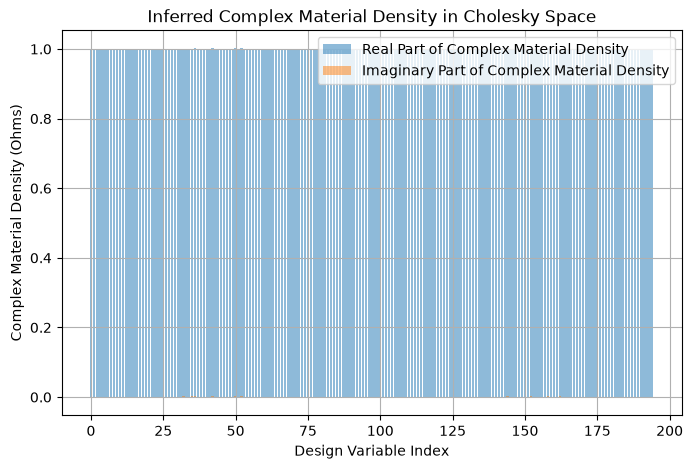

err vs full: 0.00038076701388043983


In [196]:
# Ivec = Ifull
Vopt = Z0 @ Ivec
Vinf = Vinc - Vopt

sigmaInf = Ivec/Vinf
sigmaFull = 1/Zs

complexMaterialDensity = sigmaInf/sigmaFull

# bar plot with real and imaginary parts of Zinf for Ndes design variables
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.bar(np.arange(Ndes), np.real(complexMaterialDensity), alpha=0.5, label='Real Part of Complex Material Density')
plt.bar(np.arange(Ndes), np.imag(complexMaterialDensity), alpha=0.5, label='Imaginary Part of Complex Material Density')
plt.xlabel('Design Variable Index')
plt.ylabel('Complex Material Density (Ohms)')
plt.title('Inferred Complex Material Density in Cholesky Space')
plt.legend()
plt.grid(True)
plt.show()

print(f"err vs full: {np.linalg.norm(Ivec - Ifull)/np.linalg.norm(Ifull)}")
